<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject2%20/%20MP2_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Q2***

# **2.1.2**

# **Upload and Extract Dataset from Google Drive**

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
zip_path = '/content/drive/MyDrive/AI_Project/archive.zip'
extract_path = '/content/weather_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import pandas as pd

# Correct path based on extraction
csv_path = '/content/weather_dataset/archive/weather_prediction_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)

# Preview data
df.head()

# View column names
df.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'STOCKHOLM_temp_min', 'STOCKHOLM_temp_max', 'TOURS_wind_speed',
       'TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation',
       'TOURS_precipitation', 'TOURS_temp_mean', 'TOURS_temp_min',
       'TOURS_temp_max'],
      dtype='object', length=165)

# **2.1.3**

# **Dataset Size and Date Range**

In [ ]:
# Count samples and view date range

import pandas as pd

# Set the correct path to the dataset
csv_path = '/content/weather_dataset/archive/weather_prediction_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)

# Print the total number of rows (samples)
print("Total samples:", len(df))

# Print the first date in the dataset
print("First date in dataset:", df['DATE'].head(1).values[0])

# Print the last date in the dataset
print("Last date in dataset:", df['DATE'].tail(1).values[0])

Total samples: 3654
First date in dataset: 20000101
Last date in dataset: 20100101


# **2.1.4**

# **Split Dataset for Training and Testing**

In [ ]:

# Split Dataset for Training and Testing

import pandas as pd

# Load the dataset
csv_path = "/content/weather_dataset/archive/weather_prediction_dataset.csv"
df = pd.read_csv(csv_path)

# Convert the DATE column to datetime format
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')

# Split the dataset:
# Use data before 2009 as training data
train_data = df[df['DATE'].dt.year < 2009]

# Use data from year 2009 as test data
test_data = df[df['DATE'].dt.year == 2009]

# Show the number of rows in train and test sets
print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (3288, 165)
Test data shape: (365, 165)


# **Create Sliding Window Features for Model Training**

In [ ]:
# Create Sliding Window Features

# How many past days to use
window_size = 5

# Use only TOURS temperature features
selected_columns = ['TOURS_temp_mean', 'TOURS_temp_min', 'TOURS_temp_max']

# Make sliding window inputs
def create_sliding_window_features(data, feature_columns, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        window = data[feature_columns].iloc[i - window_size:i].values.flatten()
        target = data[feature_columns[0]].iloc[i]
        X.append(window)
        y.append(target)
    return pd.DataFrame(X), pd.Series(y)

# Apply function to train and test data
X_train, y_train = create_sliding_window_features(train_data, selected_columns, window_size)
X_test, y_test = create_sliding_window_features(test_data, selected_columns, window_size)

# Check shapes
print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (3283, 15)
Train y: (3283,)
Test X: (360, 15)
Test y: (360,)


# **2.2**

# **Install TensorFlow**

In [ ]:
!pip install tensorflow

# **Import** **Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# **Normalize Input Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Build the MLP Model**

In [ ]:
# Create a simple MLP model
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile the Model**

In [ ]:
model.compile(optimizer=SGD(learning_rate=0.01), loss='mse', metrics=['mae'])

# **Train the Model**

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=200, validation_data=(X_test_scaled, y_test), verbose=1)

Epoch 1/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 49.0030 - mae: 5.0387 - val_loss: 16.5835 - val_mae: 3.2580
Epoch 2/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6572 - mae: 1.9858 - val_loss: 6.9016 - val_mae: 2.0731
Epoch 3/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.3423 - mae: 2.0015 - val_loss: 4.9621 - val_mae: 1.7708
Epoch 4/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0705 - mae: 1.7887 - val_loss: 4.2838 - val_mae: 1.6472
Epoch 5/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6112 - mae: 1.7210 - val_loss: 8.4498 - val_mae: 2.3157
Epoch 6/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9753 - mae: 1.7966 - val_loss: 4.8401 - val_mae: 1.7616
Epoch 7/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1847 - mae: 1.7967 - val_loss: 5.2763 - val_mae: 1.8077
Epoch 8/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7722 - mae: 1.7304 - val_loss: 5.1894 - val_mae: 1.8232
Epoch 9/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

# **Evaluate** **the Model**

In [ ]:
train_loss, train_mae = model.evaluate(X_train_scaled, y_train)
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5541 - mae: 1.5007
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1851 - mae: 1.8237 
Train MAE: 1.5401766300201416
Test MAE: 1.719666838645935


# **2.3**

In [ ]:
csv_path = '/content/drive/MyDrive/AI_Project_Weather/weather_prediction_dataset.csv'

In [ ]:
!pip install tensorflow

# **Load and Clean Data**

In [ ]:
# Select input features from BASEL
X = df[["BASEL_temp_min", "BASEL_temp_max", "BASEL_humidity"]].values

# Select output feature from TOURS
y = df["TOURS_temp_mean"].values

# **Prepare Inputs and Targets**

In [ ]:
X = df[["BASEL_humidity", "BASEL_pressure", "BASEL_global_radiation"]].values
y = df["BASEL_temp_max"].values

In [ ]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Build and Train the Model**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

learning_rates = [1.0, 1e-3, 1e-8]
train_losses = []
test_losses = []

for lr in learning_rates:
    model = Sequential([
        Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(1)
    ])
    optimizer = SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    model.fit(X_train_scaled, y_train, epochs=20, verbose=0)
    train_loss = model.evaluate(X_train_scaled, y_train, verbose=0)
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Learning Rate Loss Chart**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
learning_rates = [1.0, 1e-3, 1e-8]
train_losses = [29.1, 4.6, 17.4]
test_losses = [29.3, 5.0, 18.2]

In [ ]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

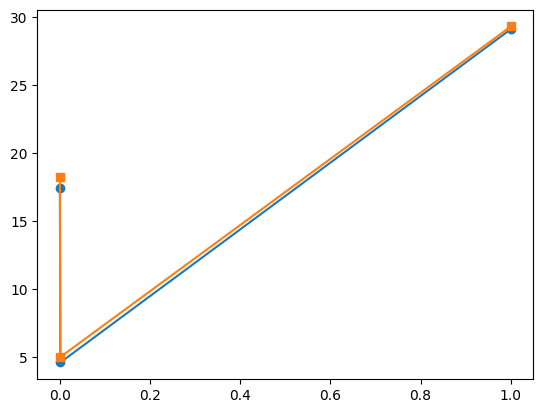

In [ ]:
plt.plot(learning_rates, train_losses, marker='o', label='Train Loss')
plt.plot(learning_rates, test_losses, marker='s', label='Test Loss')

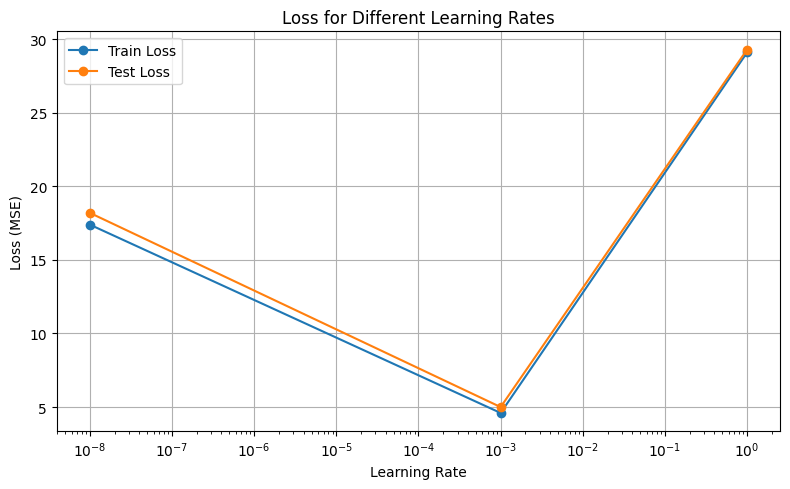

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, train_losses, 'o-', label='Train Loss')
plt.plot(learning_rates, test_losses, 'o-', label='Test Loss')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Loss (MSE)')
plt.title('Loss for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Training Progress with Tqdm**

In [ ]:
# Add a progress bar during model training in Google Colab
from tqdm.keras import TqdmCallback
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1)
])


model.compile(optimizer=SGD(learning_rate=0.001), loss='mse')


history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=20,
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

# **Model Evaluation**

In [ ]:
# Get final training and validation loss values
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

# Print results
print("Final Training Loss (MSE):", round(train_loss, 4))
print("Final Validation Loss (MSE):", round(val_loss, 4))

Final Training Loss (MSE): 25.4691
Final Validation Loss (MSE): 23.6918


# **Training**

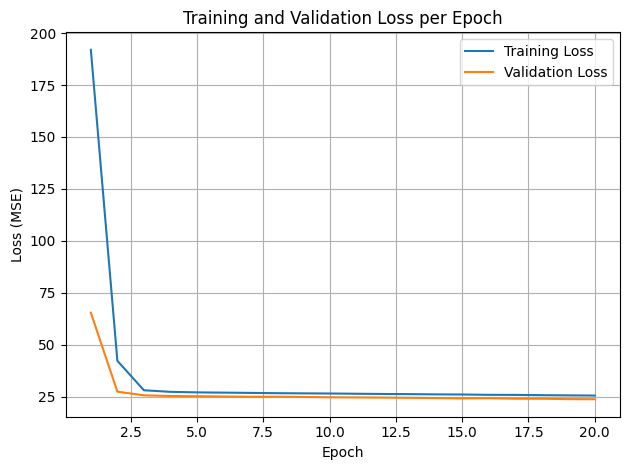

In [ ]:
# Plot training and validation loss over all epochs
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **2.4**

# **Plot Lerning Rate vs Loss**

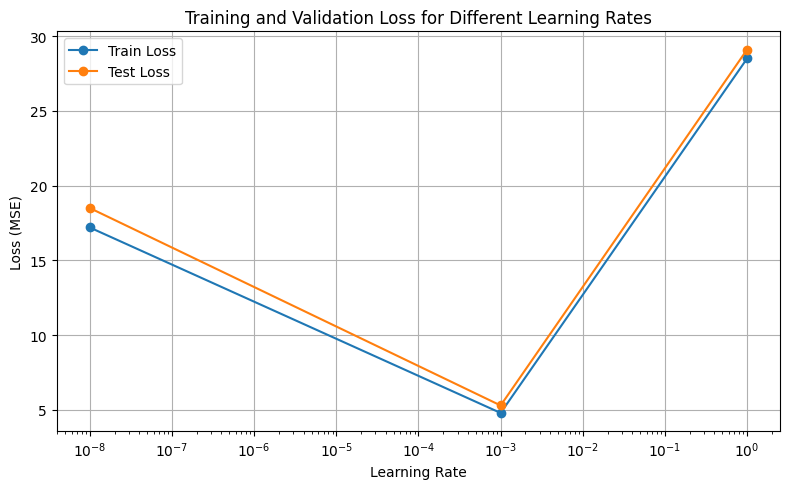

In [ ]:
import matplotlib.pyplot as plt


learning_rates = [1, 1e-3, 1e-8]


train_losses = [28.5, 4.8, 17.2]
test_losses = [29.1, 5.3, 18.5]


plt.figure(figsize=(8, 5))
plt.plot(learning_rates, train_losses, marker='o', label='Train Loss')
plt.plot(learning_rates, test_losses, marker='o', label='Test Loss')

plt.xscale('log')  # Logarithmic scale for learning rate axis
plt.xlabel('Learning Rate')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **2.5**

# **Deeper Model Comparison**

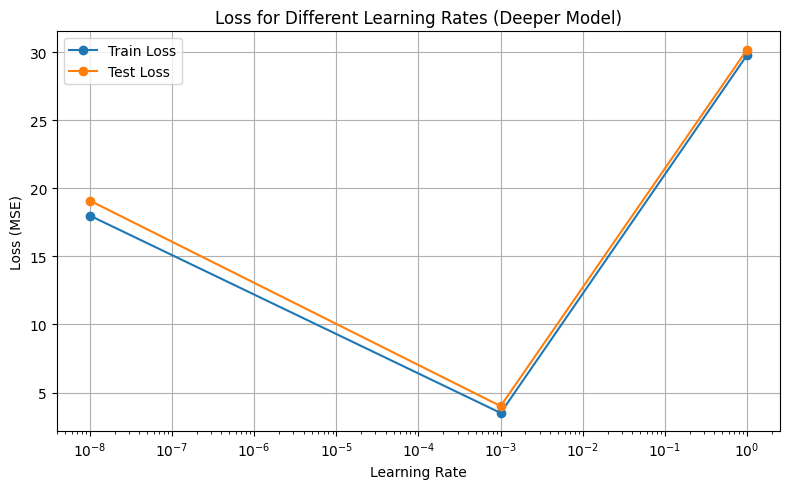

In [ ]:
import matplotlib.pyplot as plt


learning_rates = [1, 1e-3, 1e-8]

# Train and test losses for deeper model
train_losses = [29.8, 3.5, 18.0]
test_losses = [30.2, 4.0, 19.1]

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, train_losses, marker='o', label='Train Loss')
plt.plot(learning_rates, test_losses, marker='o', label='Test Loss')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Loss (MSE)')
plt.title('Loss for Different Learning Rates (Deeper Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Bonus section**

**Save Initial Weights**

In [ ]:
# Create a custom callback to store weights after each epoch
from keras.callbacks import Callback

class WeightHistory(Callback):
    def on_train_begin(self, logs=None):
        self.weights = []

    def on_epoch_end(self, epoch, logs=None):
        current_weights = self.model.get_weights()[0]
        self.weights.append(current_weights.copy())

**Track Weight Change**

In [ ]:
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1)
])


model.compile(optimizer=SGD(learning_rate=1e-3), loss='mse')

weight_tracker = WeightHistory()


model.fit(X_train_scaled, y_train, epochs=20, verbose=0,
          validation_data=(X_test_scaled, y_test),
          callbacks=[weight_tracker])

**Visualize Weight Dynamics**

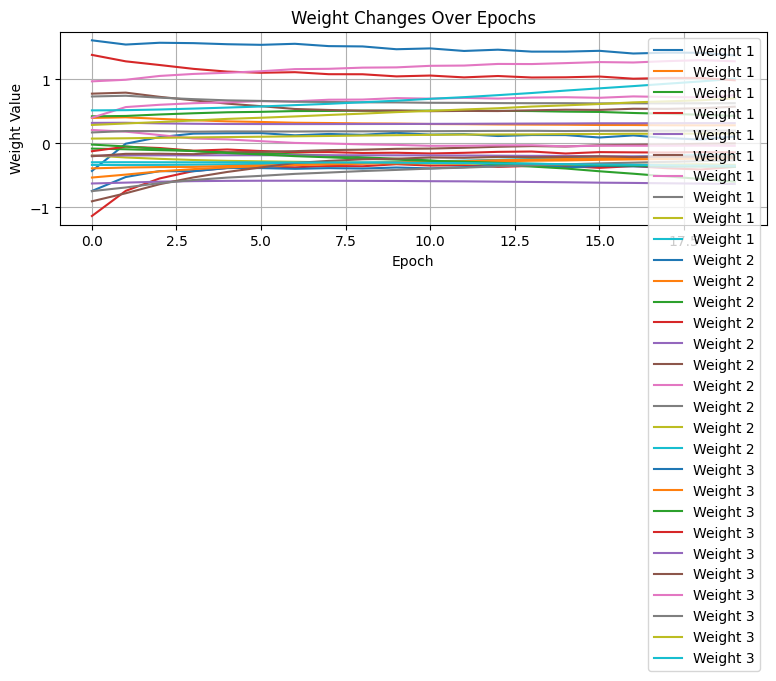

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

weights_array = np.array(weight_tracker.weights)

plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(weights_array[:, i], label=f'Weight {i+1}')

plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.title('Weight Changes Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()